## 1. Load the Libraries

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

For this tutorial, we’ll use a physiology dataset — specifically the FEV (Forced Expiratory Volume) dataset, a classic life-science example where we predict lung function from age or height (one predictor → continuous target). 

## 2. Load the Dataset

If your dataset is locally saved as fev.text, load it:

In [14]:
fev_source = 'https://raw.githubusercontent.com/GTPB/PSLS20/master/data/fev.txt'

In [15]:
fev = pd.read_csv(fev_source, sep = '\t')

In [16]:
fev.shape

(606, 5)

In [17]:
fev.head()

,age,fev,height,gender,smoking
0,9,1.708,57.0,f,0
1,8,1.724,67.5,f,0
2,7,1.720,54.5,f,0
3,9,1.558,53.0,m,0
4,9,1.895,57.0,m,0


## 3. Explore the Data

Before modeling, understand relationships with visualizations.

<Axes: xlabel='count', ylabel='gender'>

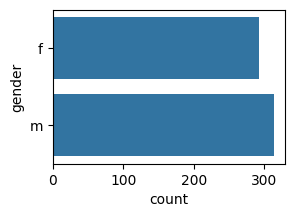

In [18]:
plt.figure(figsize=(3,2))
sns.countplot(fev['gender'])

In [19]:
fev['gender'].value_counts()

gender
m    314
f    292
Name: count, dtype: int64

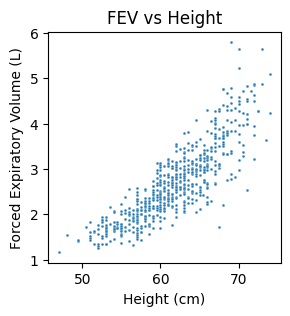

In [20]:
plt.figure(figsize=(3,3))
sns.scatterplot(x="height", y="fev", data=fev, s = 4)
plt.title("FEV vs Height")
plt.xlabel("Height (cm)")
plt.ylabel("Forced Expiratory Volume (L)")
plt.show()

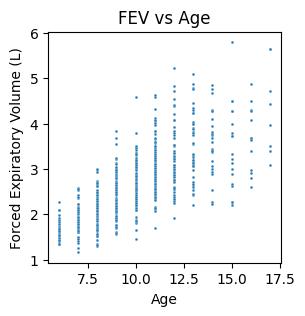

In [21]:
plt.figure(figsize=(3,3))
sns.scatterplot(x="age", y="fev", data=fev, s = 4)
plt.title("FEV vs Age")
plt.xlabel("Age")
plt.ylabel("Forced Expiratory Volume (L)")
plt.show()

## 4. Split Features and Labels
Separate inputs (X) and outputs (y):

In [22]:
X = fev[["height"]].values   # 2D array for sklearn
y = fev["fev"].values        # 1D array target

## 5. Train/Test Split
Reserve a portion of data for evaluation:

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [24]:
X_train.shape

(424, 1)

In [25]:
X_test.shape

(182, 1)

## 6. Fit the Linear Regression Model
Create and train the model

In [26]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 7. Inspect the model

In [27]:
print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

Slope (Coefficient): 0.13367323369679526
Intercept: -5.562303886933788


📌 Interpretation:

- Slope: How much FEV increases (on average) per unit increase in height.
- Intercept: Predicted FEV when height = 0 (used for formula completeness but not biologically meaningful here).

## 8. Evaluate the Model


In [28]:
y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R² Score: 0.7743184296642249
Mean Squared Error: 0.16334173308363634


## 9. Visualize the regression line

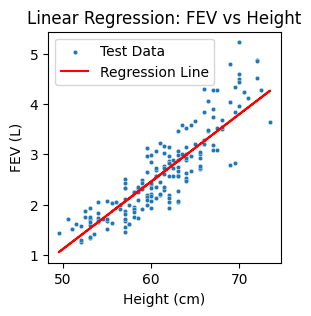

In [29]:
plt.figure(figsize=(3,3))
sns.scatterplot(x=X_test.flatten(), y=y_test, label="Test Data", s= 10)
plt.plot(X_test, y_pred, color="red", label="Regression Line")
plt.xlabel("Height (cm)")
plt.ylabel("FEV (L)")
plt.title("Linear Regression: FEV vs Height")
plt.legend()
plt.show()

## 10. Further Interpretations

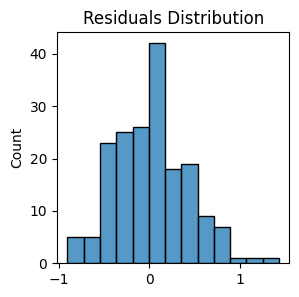

In [30]:
plt.figure(figsize=(3,3))
residuals = y_test - y_pred
sns.histplot(residuals)
plt.title("Residuals Distribution")
plt.show()

In [31]:
fev.head()

,age,fev,height,gender,smoking
0,9,1.708,57.0,f,0
1,8,1.724,67.5,f,0
2,7,1.720,54.5,f,0
3,9,1.558,53.0,m,0
4,9,1.895,57.0,m,0


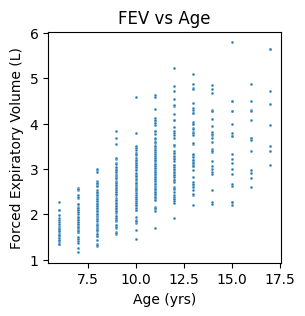

In [32]:
plt.figure(figsize=(3,3))
sns.scatterplot(x="age", y="fev", data=fev, s = 4)
plt.title("FEV vs Age")
plt.xlabel("Age (yrs)")
plt.ylabel("Forced Expiratory Volume (L)")
plt.show()

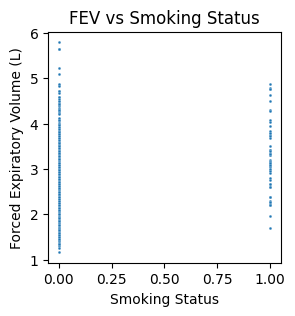

In [33]:
plt.figure(figsize=(3,3))
sns.scatterplot(x="smoking", y="fev", data=fev, s = 4)
plt.title("FEV vs Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Forced Expiratory Volume (L)")
plt.show()